In [1]:

import numpy as np
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import pandas as pd

import seaborn as sns

import healpy as hp

from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.cosmology import LambdaCDM

from config.plotting import set_inverted_defaults, set_plotting_defaults

In [2]:
# Set default font size
mpl.rcParams['font.size'] = 12

### Process the Neronov-Semikoz catalog

In [3]:
# load NS catalog
ns_catalog = pd.read_csv("./galcats/ns/nscat_total.csv", index_col=0)

In [16]:
ns_catalog = ns_catalog.query("0.01 < z < 0.51")
ns_catalog

,4FGL,RA,Dec,N100,N300,Gamma,Gamma_err,z,F100,F100_err_low,F100_err_high,Type,HSP,Table
ID,,,,,,,,,,,,,,
8,NGC 1275,49.958,41.512,11(12),1,2.123,0.005,0.017,3.0,0.7,1.0,RDG,NaN,0
52,H 1722+119,261.271,11.875,8(10),2,1.869,0.019,0.018,2.5,0.7,0.9,BLL,NaN,0
7,IC 310,49.215,41.346,3(5),1,1.882,0.124,0.019,1.2,0.4,0.7,RDG,NaN,0
20,4C +39.12,53.582,39.339,2(4),1,1.820,0.100,0.020,1.0,0.4,0.6,RDG,NaN,2
69,NGC 6251,247.669,82.574,2(2),0,2.350,0.020,0.020,0.4,0.2,0.4,RDG,NaN,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49,RX J1117.2+0006,169.301,0.144,2(2),0,1.700,0.110,0.451,0.6,0.3,0.6,BLL,E,3
54,RX J1211.9+2242,183.015,22.709,2(2),0,1.970,0.110,0.453,0.5,0.3,0.5,BLL,E,3
52,4FGL J1158.8-1430,179.709,-14.501,1(3),0,1.720,0.130,0.480,0.8,0.4,0.6,BCU,NaN,3


In [17]:
MW_plane = SkyCoord(l=np.linspace(0, 360, 100), b=0.0, frame='galactic', unit='deg').galactic
theta_MW, phi_MW = np.pi/2 - MW_plane.b.rad, MW_plane.l.rad

EQ_plane = SkyCoord(ra=np.linspace(0, 360, 100), dec=0.0, frame='icrs', unit='deg').galactic
theta_EQ, phi_EQ = np.pi/2 - EQ_plane.b.rad, EQ_plane.l.rad

SG_plane = SkyCoord(sgl=np.linspace(0, 360, 100), sgb=0, frame='supergalactic', unit='deg').galactic
theta_SG, phi_SG = np.pi/2 - SG_plane.b.rad, SG_plane.l.rad

### Load LSS maps

In [18]:
import os
from scipy.interpolate import RegularGridInterpolator

ovd_files = os.listdir('./overdensity')
z_start, z_end = [float(f[4:7])/100 for f in ovd_files], [float(f[8:11])/100 for f in ovd_files]

zbins = z_start.copy()
zbins.append(z_end[-1])

maps_d = np.array([np.load(f"./overdensity/{f}") for f in ovd_files])
maps = np.zeros([maps_d.shape[0] + 2, maps_d.shape[1]])
maps[1:-1] = maps_d

z_data = np.zeros(len(z_start)+2)
z_data[1:-1] = 0.5 * (np.array(z_start) + np.array(z_end))
z_data[-1] = 0.5
### extend grid with zero maps @ z = 0.0 and z = 0.5

nside = hp.get_nside(maps[0])
npix = hp.get_map_size(maps[0])
pix_data = np.arange(0, npix, 1)

zp_interpolator = RegularGridInterpolator(
    (z_data, pix_data),
    maps,
    bounds_error=False,
    fill_value=0
)

In [25]:
z_grid = np.linspace(0, 1.0, 200)

zpx, pxz = np.meshgrid(z_grid, pix_data, indexing='ij')

maps_interp = zp_interpolator((zpx, pxz))

#### make a movie

In [8]:
# import matplotlib.pyplot as plt
# import matplotlib.animation as animation
# import healpy as hp

# # Initialize a clean figure
# fig = plt.figure()

# def update(i):
#     # 1. Clear the figure so titles, maps, and colorbars don't overlap
#     plt.clf() 
    
#     # 2. Draw the map for the current frame
#     hp.mollview(
#         maps_interp[i], 
#         title=f"z = {z_grid[i]:.4f}", 
#         min=-2, 
#         max=2, 
#         cmap='coolwarm', 
#         coord=['C', 'G'],
#         hold=True  # Tells healpy to use the existing figure instead of creating a new window
#     )

# # Create the animation using FuncAnimation
# ani = animation.FuncAnimation(
#     fig, 
#     update, 
#     frames=len(z_grid), 
#     interval=50, 
#     repeat_delay=1000
# )

# writer = animation.FFMpegWriter(
#     fps=5, metadata=dict(artist='Me'), bitrate=1800)
# ani.save("./figures/movie.mp4", writer=writer)

# # To display it in a Jupyter Notebook, you can uncomment the line below:
# from IPython.display import HTML
# HTML(ani.to_jshtml())

### LOS interpolation

In [26]:
ns_catalog = ns_catalog.sort_values(by="z")

pixs = hp.ang2pix(nside, theta=np.pi/2 - np.deg2rad(ns_catalog["Dec"]), phi=np.deg2rad(ns_catalog["RA"]))

zpx_ns, pxz_ns = np.meshgrid(z_grid, pixs, indexing='ij')
weights = zpx_ns < np.array(ns_catalog["z"])
values = zp_interpolator((zpx_ns, pxz_ns)) * weights

In [10]:
# set_inverted_defaults()
# fig = plt.figure(figsize=(12, 6))
# gs = GridSpec(2, 1, height_ratios=[59, 79], figure=fig, hspace=0.02)

# ax = plt.subplot(gs[0])
# ax.pcolormesh(np.arange(0, 190), z_grid, values, cmap='coolwarm', vmin=-1, vmax=1, rasterized=True)
# ax.pcolormesh(np.arange(0, 190), z_grid, weights, alpha=~weights, cmap='Greys_r', vmin=0, vmax=1, rasterized=True)
# ax.scatter(np.arange(0, 190), ns_catalog["z"], s=10, color='limegreen')
# for i, ind in enumerate(ns_catalog.index):
#     if i > 94:
#         continue
#     weight = "bold" if ns_catalog["HSP"][ind] == "E" else "normal"
#     ax.text(i-0.35, ns_catalog["z"][ind] + 0.02, ns_catalog["4FGL"][ind], fontsize=6, rotation=90,
#             weight=weight, color='white')
# ax2 = ax.secondary_yaxis(location='right')
# ax.set_xticks([])
# ax.set_xlim([-0.5, 94.5])
# ax.set_ylim([0, 0.59])
# ax.set_ylabel('redshift')
# ax.grid(False)
# ax2.grid(False)


# # ------------

# ax = plt.subplot(gs[1])
# ax.pcolormesh(np.arange(0, 190), z_grid, values, cmap='coolwarm', vmin=-1, vmax=1, rasterized=True)
# ax.pcolormesh(np.arange(0, 190), z_grid, weights, alpha=~weights, cmap='Greys_r', vmin=0, vmax=1, rasterized=True)
# ax.scatter(np.arange(0, 190), ns_catalog["z"], s=10, color='limegreen')
# for i, ind in enumerate(ns_catalog.index):
#     if i < 95:
#         continue
#     weight = "bold" if ns_catalog["HSP"][ind] == "E" else "normal"
#     ax.text(i-0.35, ns_catalog["z"][ind] + 0.02, ns_catalog["4FGL"][ind], fontsize=6, rotation=90,
#             weight=weight, color='white')
# ax2 = ax.secondary_yaxis(location='right')

# ax.set_xticks([])
# ax.set_xlim([94.5, 189.5])
# ax.set_ylim([0, 0.79])
# ax.set_ylabel("redshift")
# ax.grid(False)
# ax2.grid(False)

# plt.tight_layout()
# plt.savefig("./figures/lss-ns-zsorted_pres.pdf", bbox_inches='tight', pad_inches=0.05, transparent=True)
# plt.show()

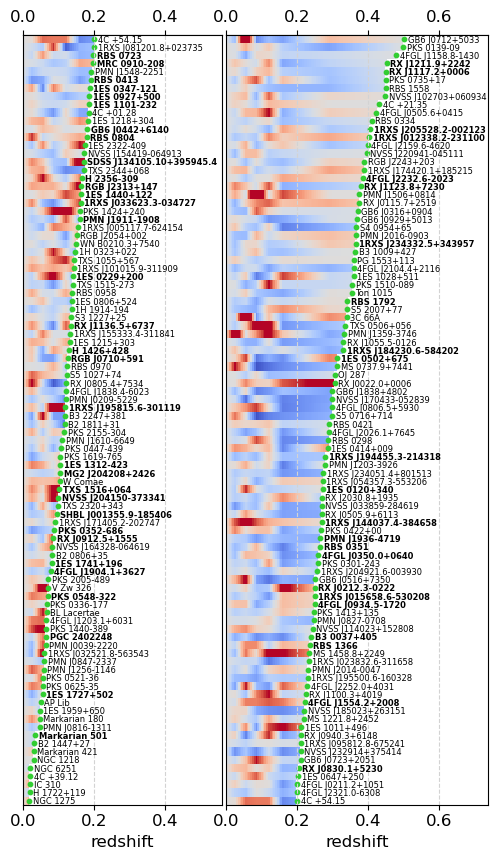

In [43]:
set_plotting_defaults()
fig = plt.figure(figsize=(6, 10))
gs = GridSpec(1, 2, width_ratios=[56, 74], figure=fig, wspace=0.02)

nz = len(ns_catalog['z'])

ax = plt.subplot(gs[0])
ax.pcolormesh(z_grid, np.arange(0, nz), values.T, cmap='coolwarm', vmin=-1, vmax=1, rasterized=True)
ax.pcolormesh(z_grid, np.arange(0, nz), weights.T, alpha=~weights.T, cmap='Grays', vmin=0, vmax=1, rasterized=True)
ax.scatter(ns_catalog["z"], np.arange(0, nz), s=10, color='limegreen')

counter = 0
for i, row in ns_catalog.iterrows():
    if counter < 94:
        weight = "bold" if row["HSP"] == "E" else "normal"
        ax.text(row["z"] + 0.01, counter-0.45, row["4FGL"], fontsize=6, rotation=0,
                weight=weight)
    counter += 1
ax2 = ax.secondary_xaxis(location='top')

ax.set_yticks([])
ax.set_ylim([-0.5, 93.5])
ax.set_xlim([0, 0.56])
ax.set_xlabel("redshift")

ax = plt.subplot(gs[1])
ax.pcolormesh(z_grid, np.arange(0, nz), values.T, cmap='coolwarm', vmin=-1, vmax=1, rasterized=True)
ax.pcolormesh(z_grid, np.arange(0, nz), weights.T, alpha=~weights.T, cmap='Grays', vmin=0, vmax=1, rasterized=True)
ax.scatter(ns_catalog["z"], np.arange(0, nz), s=10, color='limegreen')

counter = 0
for i, row in ns_catalog.iterrows():
    if counter > 92:
        weight = "bold" if row["HSP"] == "E" else "normal"
        ax.text(row["z"] + 0.01, counter-0.45, row["4FGL"], fontsize=6, rotation=0,
                weight=weight)
    counter += 1
ax2 = ax.secondary_xaxis(location='top')

ax.set_yticks([])
ax.set_ylim([92.5, 186.5])
ax.set_xlim([0, 0.74])
ax.set_xlabel("redshift")

# plt.savefig("./figures/lss-ns-zsorted_pres.pdf", bbox_inches='tight', pad_inches=0.05)
plt.show()

In [44]:
ns_catalog["ovdvalue"] = np.trapz(values, z_grid, axis=0) / ns_catalog["z"]

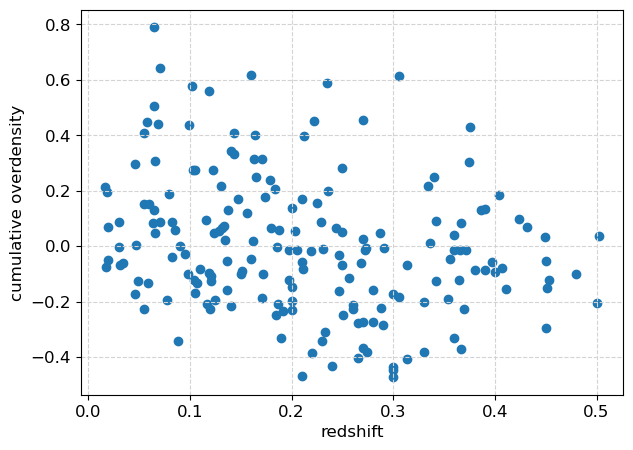

In [45]:
plt.scatter(ns_catalog["z"], ns_catalog["ovdvalue"])
plt.xlabel("redshift")
plt.ylabel("cumulative overdensity")
plt.show()

In [46]:
ns_extr = ns_catalog.query('HSP == "E"')
ns_extr

,4FGL,RA,Dec,N100,N300,Gamma,Gamma_err,z,F100,F100_err_low,F100_err_high,Type,HSP,Table,ovdvalue
ID,,,,,,,,,,,,,,,
51,Markarian 501,253.474,39.759,81(109),22,1.795,0.008,0.034,23.5,2.1,2.4,BLL,E,0,-0.059357
53,1ES 1727+502,262.078,50.227,5(11),4,1.785,0.022,0.055,2.3,0.6,0.8,BLL,E,0,-0.225119
21,PGC 2402248,113.362,51.880,3(5),1,1.769,0.079,0.065,1.2,0.4,0.7,BLL,E,0,0.130867
16,PKS 0548-322,87.625,-32.277,4(5),0,1.829,0.071,0.069,1.2,0.4,0.7,BLL,E,0,0.439651
85,4FGL J1904.1+3627,286.034,36.453,3(4),0,1.850,0.060,0.078,0.9,0.3,0.6,BLL,E,2,-0.194811
54,1ES 1741+196,266.008,19.596,3(4),0,1.922,0.043,0.080,0.9,0.4,0.6,BLL,E,0,0.187534
44,RX J0912.5+1555,138.137,15.934,3(3),1,1.790,0.090,0.085,0.8,0.3,0.6,BLL,E,2,0.059528
25,PKS 0352-686,58.274,-68.528,2(5),0,1.670,0.070,0.088,1.3,0.5,0.7,BLL,E,2,-0.341188
1,SHBL J001355.9-185406,3.480,-18.912,2(2),1,1.900,0.080,0.095,0.6,0.3,0.6,BLL,E,1,-0.029849


In [47]:
ns_lowz = ns_catalog.query('z < 0.18')
ns_lowz.head()

,4FGL,RA,Dec,N100,N300,Gamma,Gamma_err,z,F100,F100_err_low,F100_err_high,Type,HSP,Table,ovdvalue
ID,,,,,,,,,,,,,,,
8,NGC 1275,49.958,41.512,11(12),1,2.123,0.005,0.017,3.0,0.7,1.0,RDG,NaN,0,0.212016
52,H 1722+119,261.271,11.875,8(10),2,1.869,0.019,0.018,2.5,0.7,0.9,BLL,NaN,0,-0.075917
7,IC 310,49.215,41.346,3(5),1,1.882,0.124,0.019,1.2,0.4,0.7,RDG,NaN,0,0.196993
20,4C +39.12,53.582,39.339,2(4),1,1.820,0.100,0.020,1.0,0.4,0.6,RDG,NaN,2,0.068860
69,NGC 6251,247.669,82.574,2(2),0,2.350,0.020,0.020,0.4,0.2,0.4,RDG,NaN,3,-0.050054


In [48]:
ns_obs = ns_catalog.query('Table < 2')
ns_obs.head()

,4FGL,RA,Dec,N100,N300,Gamma,Gamma_err,z,F100,F100_err_low,F100_err_high,Type,HSP,Table,ovdvalue
ID,,,,,,,,,,,,,,,
8,NGC 1275,49.958,41.512,11(12),1,2.123,0.005,0.017,3.0,0.7,1.0,RDG,NaN,0,0.212016
52,H 1722+119,261.271,11.875,8(10),2,1.869,0.019,0.018,2.5,0.7,0.9,BLL,NaN,0,-0.075917
7,IC 310,49.215,41.346,3(5),1,1.882,0.124,0.019,1.2,0.4,0.7,RDG,NaN,0,0.196993
29,Markarian 421,166.119,38.207,232(314),69,1.785,0.004,0.030,77.6,4.3,4.5,BLL,NaN,0,0.087169
51,Markarian 501,253.474,39.759,81(109),22,1.795,0.008,0.034,23.5,2.1,2.4,BLL,E,0,-0.059357


In [49]:
ns_nonobs = ns_catalog.query('Table >= 2')
ns_nonobs.head()

,4FGL,RA,Dec,N100,N300,Gamma,Gamma_err,z,F100,F100_err_low,F100_err_high,Type,HSP,Table,ovdvalue
ID,,,,,,,,,,,,,,,
20,4C +39.12,53.582,39.339,2(4),1,1.82,0.10,0.020,1.0,0.4,0.6,RDG,NaN,2,0.068860
69,NGC 6251,247.669,82.574,2(2),0,2.35,0.02,0.020,0.4,0.2,0.4,RDG,NaN,3,-0.050054
14,NGC 1218,47.111,4.118,2(2),0,2.01,0.05,0.030,0.5,0.3,0.5,RDG,NaN,3,-0.003291
62,B2 1447+27,222.396,27.769,2(2),0,1.48,0.11,0.031,0.5,0.2,0.5,RDG,NaN,3,-0.067564
41,PMN J0816-1311,124.112,-13.197,4(4),0,1.84,0.03,0.046,1.1,0.4,0.7,BLL,NaN,2,-0.172043


ValueError: invalid literal for int() with base 10: '11(12)'

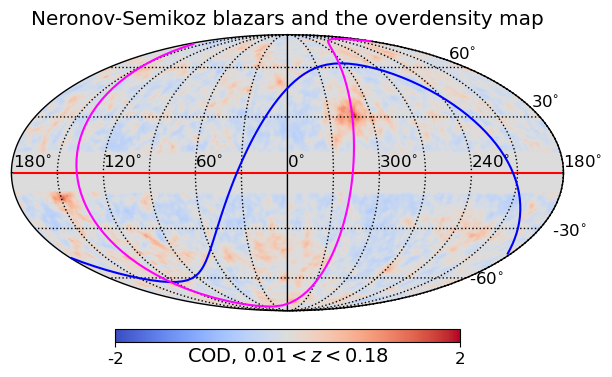

In [54]:
# plt.style.use('dark_background')
# set_inverted_defaults()

fig = plt.figure(figsize=(12, 4))
gs = GridSpec(1, 2, figure=fig, width_ratios=[7, 2], wspace=0.1)
ax =  fig.add_subplot(gs[0])
plt.sca(ax)
hp.mollview(np.average(np.array(maps)[:-1], axis=0), coord=['C', 'G'], cmap='coolwarm',
            title="Neronov-Semikoz blazars and the overdensity map",
            min=-2, max=2, cbar=True,
            unit=r'COD, $0.01 < z < 0.18$',
            notext=True, sub=None, hold=True, margins=[0, -0.10, 0, 0.05],
            bgcolor='none')

hp.graticule(color='black')

hp.projplot(theta_MW, phi_MW, color='red', coord='G')
hp.projplot(theta_EQ, phi_EQ, color='blue', coord='G')
hp.projplot(theta_SG, phi_SG, color='magenta', coord='G')

for l in range(0, 360, 60):
    hp.projtext(np.pi/2-0.04, np.deg2rad(l), f"{l}"r"$\!{}^\circ$")
    if l == 180:
        hp.projtext(np.pi/2-0.04, np.deg2rad(l-1), f"{l}"r"$\!{}^\circ$")
        
for m in range(-60, 90, 30):
    if m == 0:
        continue
    hp.projtext(np.pi/2 - np.deg2rad(m + np.sign(m) * 5), np.deg2rad(180),
                f"{'  ' * (1 - np.sign(m))}{m}"r"$\!{}^\circ$")

size = np.clip(5 * np.int_(ns_catalog["N100"]), a_min=0.0, a_max=100.0)

# ALL BLAZARS
cmap = plt.get_cmap("cool", lut=8)
p = hp.projscatter(np.pi/2 - np.deg2rad(ns_catalog["Dec"]), np.deg2rad(ns_catalog["RA"]), coord='C',
               s=size, c=ns_catalog['ovdvalue'], cmap=cmap, vmin=-0.8, vmax=0.8)
# plt.colorbar(p)

# EXTREME
size = np.clip(5 * ns_extr["N_100"], a_min=0.0, a_max=100.0)
hp.projscatter(np.pi/2 - np.deg2rad(ns_extr["Dec"]), np.deg2rad(ns_extr["RA"]), coord='C',
               marker='o', facecolor='none', s=size, color='black', linewidth=1.0, zorder=10)

ax2 = fig.add_subplot(gs[1])
plt.sca(ax2)

bs = np.arange(-1.0, 2.4, 0.1)
for x in bs:
    cat_x = ns_catalog.query("@x <= ovdvalue <= @x + 0.1")["ovdvalue"]
    x_c = ((x+0.1) / 1.6) + 0.5
    sns.histplot(y=cat_x, bins=[x, x+0.1], ax=ax2, color=cmap(x_c))
    
sns.histplot(y=ns_extr["ovdvalue"], bins=bs,
             ax=ax2, fill=False, color='black', alpha=.7,
             linewidth=3, element='step',
             label='Extreme')

sns.histplot(y=ns_lowz["ovdvalue"], bins=bs,
             ax=ax2, fill=False, color='silver', alpha=.7,
             linewidth=3, element='step',
             label='z < 0.18')

sns.histplot(y=ns_obs["ovdvalue"], bins=bs,
             ax=ax2, fill=False,
             color='orange', linewidth=3,  alpha=.7,
             element='step',
             label='Detected')

sns.histplot(y=ns_nonobs["ovdvalue"], bins=bs,
             ax=ax2, fill=False,
             color='seagreen', linewidth=3,  alpha=.7,
             element='step',
             label='Targets')

ax2.hlines([np.average(ns_catalog["ovdvalue"]),
            np.average(ns_extr["ovdvalue"]),
            np.average(ns_lowz['ovdvalue']),
            np.average(ns_obs['ovdvalue']),
            np.average(ns_nonobs['ovdvalue']),
            ],
           0.5, 100,
           colors=['navy', 'black', 'silver', 'darkorange', 'darkgreen'],
           linewidth=2,
           linestyles=['solid', 'dashed', 'dotted', 'dashdot', 'dashed'])

ax2.legend(loc=1, fontsize=9, ncol=2, handlelength=1, columnspacing=.8)

ax2.set_xlabel("number of blazars")
ax2.set_xscale('log')
ax2.set_xticks([1, 3, 10, 30, 100], [1, 3, 10, 30, 100])
ax2.set_xlim(0.5, 100)

ax2.set_ylabel("COD along the blazar's LOS", labelpad=-2)
ax2.set_yticks(np.arange(-1.6, 2.21, 0.2))
ax2.set_ylim(-0.6, 1.0)

# plt.savefig("./figures/lss-ns-blazars-pres.png", bbox_inches='tight', pad_inches=0.05, transparent=True, dpi=300)
plt.show()

In [ ]:
ns_catalog.head()

,4FGL,RA,Dec,N_100,Delta_N,N_300,Gamma,z,Type,HSP,Table,ovdvalue
14,M 82,148.947,69.667,1,3,1,2.21±0.03,0.001,SBG,NaN,1,0.000000
126,Centaurus A,201.381,-43.016,5,6,1,2.574±0.019,0.002,RDG,NaN,0,0.000000
115,M 87,187.712,12.388,5,7,0,2.064±0.028,0.004,RDG,NaN,0,0.000000
28,NGC 1275,49.958,41.512,11,12,1,2.123±0.005,0.017,RDG,NaN,0,0.212016
161,H 1722+119,261.271,11.875,8,10,2,1.869±0.019,0.018,BLL,NaN,0,-0.075917


In [55]:
ns_catalog.to_csv("./galcats/ns/nscat_total_ovd.csv")

In [ ]:
ns_extr = ns_extr.sort_values(by="ovdvalue")
ns_extr[ns_extr["Table"] == 0]

,4FGL,RA,Dec,N_100,Delta_N,N_300,Gamma,z,Type,HSP,Table,ovdvalue
31,RBS 0413,49.972,18.753,3,7,1,1.709±0.054,0.190,BLL,E,0,-0.330957
162,1ES 1727+502,262.078,50.227,5,11,4,1.785±0.022,0.055,BLL,E,0,-0.225119
62,RGB J0710+591,107.623,59.135,3,4,1,1.703±0.043,0.125,BLL,E,0,-0.192451
181,MG2 J204208+2426,310.536,24.458,4,5,1,1.947±0.052,0.104,BLL,E,0,-0.122265
45,1ES 0502+675,76.996,67.622,25,34,6,1.589±0.02,0.314,BLL,E,0,-0.067367
157,Markarian 501,253.474,39.759,81,109,22,1.795±0.008,0.034,BLL,E,0,-0.059357
76,MRC 0910-208,138.227,-21.045,6,11,1,1.816±0.038,0.198,BLL,E,0,-0.014732
87,1ES 1101-232,165.909,-23.496,1,6,1,1.699±0.06,0.186,BLL,E,0,-0.003956
138,H 1426+428,217.129,42.678,9,11,4,1.659±0.038,0.129,BLL,E,0,0.053325
36,1ES 0347-121,57.354,-11.994,3,3,1,1.854±0.063,0.188,BLL,E,0,0.057286


In [ ]:
ns_extr[ns_extr["Table"] == 1]

,4FGL,RA,Dec,N_100,Delta_N,N_300,Gamma,z,Type,HSP,Table,ovdvalue
6,RBS 0723,131.812,11.569,2,2,0,1.77±0.06,0.198,BLL,E,1,-0.122200
3,SHBL J001355.9-185406,3.480,-18.912,2,2,1,1.9±0.08,0.095,BLL,E,1,-0.029849
20,1ES 1440+122,220.698,12.013,1,4,0,1.76±0.05,0.163,BLL,E,1,0.312754


In [ ]:
ns_extr[ns_extr["Table"] == 2]

,4FGL,RA,Dec,N_100,Delta_N,N_300,Gamma,z,Type,HSP,Table,ovdvalue
250,PMN J1936-4719,294.242,-47.340,3,3,0,1.82±0.05,0.265,BLL,E,2,-0.403615
79,PKS 0352-686,58.274,-68.528,2,5,0,1.67±0.07,0.088,BLL,E,2,-0.341188
47,RBS 0351,41.158,-58.326,5,6,0,1.72±0.04,0.265,BLL,E,2,-0.275883
251,1RXS J194455.3-214318,296.229,-21.722,3,6,0,1.84±0.04,0.280,BLL,E,2,-0.272251
75,4FGL J0350.0+0640,57.504,6.675,3,3,0,1.47±0.18,0.260,BCU,E,2,-0.213827
235,1RXS J184230.6-584202,280.611,-58.680,2,3,0,1.73±0.09,0.330,BLL,E,2,-0.201121
239,4FGL J1904.1+3627,286.034,36.453,3,4,0,1.85±0.06,0.078,BLL,E,2,-0.194811
265,RBS 1792,328.282,-0.693,3,3,0,1.86±0.12,0.342,BLL,E,2,-0.124524
261,1RXS J205528.2-002123,313.853,-0.340,3,3,1,1.8±0.07,0.407,BLL,E,2,-0.077931
242,PMN J1911-1908,287.868,-19.149,2,4,0,1.87±0.07,0.160,BLL,E,2,-0.045079


In [ ]:
ns_extr[ns_extr["Table"] == 3]

,4FGL,RA,Dec,N_100,Delta_N,N_300,Gamma,z,Type,HSP,Table,ovdvalue
10,B3 0037+405,10.099,40.836,1,3,1,1.88±0.11,0.240,BLL,E,3,-0.431086
120,1ES 0927+500,142.625,49.858,2,2,0,1.85±0.13,0.187,BLL,E,3,-0.208617
151,RX J1117.2+0006,169.301,0.144,2,2,0,1.7±0.11,0.451,BLL,E,3,-0.149070
154,RX J1123.8+7230,170.959,72.513,2,2,0,1.65±0.11,0.380,BLL,E,3,-0.087055
33,1RXS J015658.6-530208,29.233,-53.031,2,2,0,1.78±0.05,0.250,BLL,E,3,-0.068332
110,RX J0830.1+5230,127.511,52.531,2,2,0,1.78±0.13,0.205,BLL,E,3,-0.015131
24,1ES 0120+340,20.791,34.354,2,2,0,1.69±0.08,0.272,BLL,E,3,-0.013923
61,GB6 J0442+6140,70.678,61.705,2,2,0,1.96±0.08,0.180,BLL,E,3,0.064408
245,4FGL J2232.6-2023,338.172,-20.391,2,2,0,1.96±0.12,0.386,BLL,E,3,0.129212
252,RGB J2313+147,348.508,14.753,2,2,0,1.82±0.05,0.164,BLL,E,3,0.399808
